# Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud

# Data Processing

## Strength Traits for All Players

In [7]:
df_strength = pd.read_excel("scouting_traits_processed.xlsx", sheet_name=0)

# standardize column names
df_strength.columns = (
    df_strength.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# filter to only "D" and "F position"
df_strength = df_strength[df_strength["position"].isin(["D", "F"])]

# filter out the "miscleneaous" trait
trait_order = ["physical", "psychological", "tactical", "technical"]
df_strength = df_strength[df_strength["trait"].isin(trait_order)]

## Weakness Traits for All Players

In [10]:
df_weakness = pd.read_excel("scouting_traits_processed.xlsx", sheet_name=1)

# standardize column names
df_weakness.columns = (
    df_weakness.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# filter to only "D" and "F position"
df_weakness = df_weakness[df_weakness["position"].isin(["D", "F"])]

# filter out the "miscleneaous" trait
df_weakness = df_weakness[df_weakness["trait"].isin(trait_order)]

# Results

## 1. Trait Distribution by Position

### Data Wrangling: Strength Traits

In [11]:
# count number of traits per (position, player_name, and trait)
counts_strength = (
    df_strength.groupby(["position", "player_name", "trait"])
      .size()
      .reset_index(name="n")
)

# ensure every player has all traits, even if zero
players_strength = df_strength[["position", "player_name"]].drop_duplicates()

template_strength = (
    players_strength.assign(key=1)
           .merge(pd.DataFrame({"trait": trait_order, "key": 1}), on="key")
           .drop(columns="key")
)

# merge observed counts; fill missing with 0
counts_full_strength = (
    template_strength.merge(counts_strength, on=["position", "player_name", "trait"], how="left")
            .fillna({"n": 0})
)

# convert raw counts to proportions per player
totals_strength = counts_full_strength.groupby(["position", "player_name"])["n"].transform("sum")
counts_full_strength["prop"] = np.where(totals_strength > 0, counts_full_strength["n"] / totals_strength, 0)

# summaries for mean % and 95% CI
summary_strength = (
    counts_full_strength.groupby(["position", "trait"], as_index=False)
               .agg(
                   mean_prop=("prop", "mean"),
                   sd_prop=("prop", "std"),
                   n_players=("player_name", "nunique")
               )
)

# compute standard error + CI
summary_strength["sem"] = summary_strength["sd_prop"] / np.sqrt(summary_strength["n_players"])
summary_strength["ci95"] = 1.96 * summary_strength["sem"]

# convert to percentages for plotting
summary_strength["mean_pct"] = 100 * summary_strength["mean_prop"]
summary_strength["ci95_pct"] = 100 * summary_strength["ci95"]

# ensure trait ordering
summary_strength["trait"] = pd.Categorical(summary_strength["trait"], categories=trait_order, ordered=True)
summary_strength = summary_strength.sort_values(["position", "trait"])

### Data Wrangling: Weakness Traits

In [12]:
# count number of traits per (position, player_name, and trait)
counts_weakness = (
    df_weakness.groupby(["position", "player_name", "trait"])
      .size()
      .reset_index(name="n")
)

# ensure every player has all traits, even if zero
players_weakness = df_weakness[["position", "player_name"]].drop_duplicates()

template_weakness = (
    players_weakness.assign(key=1)
           .merge(pd.DataFrame({"trait": trait_order, "key": 1}), on="key")
           .drop(columns="key")
)

# merge observed counts; fill missing with 0
counts_full_weakness = (
    template_weakness.merge(counts_weakness, on=["position", "player_name", "trait"], how="left")
            .fillna({"n": 0})
)

# convert raw counts to proportions per player
totals_weakness = counts_full_weakness.groupby(["position", "player_name"])["n"].transform("sum")
counts_full_weakness["prop"] = np.where(totals_weakness > 0, counts_full_weakness["n"] / totals_weakness, 0)

# summaries for mean % + 95% CI
summary_weakness = (
    counts_full_weakness.groupby(["position", "trait"], as_index=False)
               .agg(
                   mean_prop=("prop", "mean"),
                   sd_prop=("prop", "std"),
                   n_players=("player_name", "nunique")
               )
)

# compute standard error + CI
summary_weakness["sem"] = summary_weakness["sd_prop"] / np.sqrt(summary_weakness["n_players"])
summary_weakness["ci95"] = 1.96 * summary_weakness["sem"]

# convert to percentages for plotting
summary_weakness["mean_pct"] = 100 * summary_weakness["mean_prop"]
summary_weakness["ci95_pct"] = 100 * summary_weakness["ci95"]

# ensure trait ordering
summary_weakness["trait"] = pd.Categorical(summary_weakness["trait"], categories=trait_order, ordered=True)
summary_weakness = summary_weakness.sort_values(["position", "trait"])

### Figure 2: Bar Chart & Radar Chart

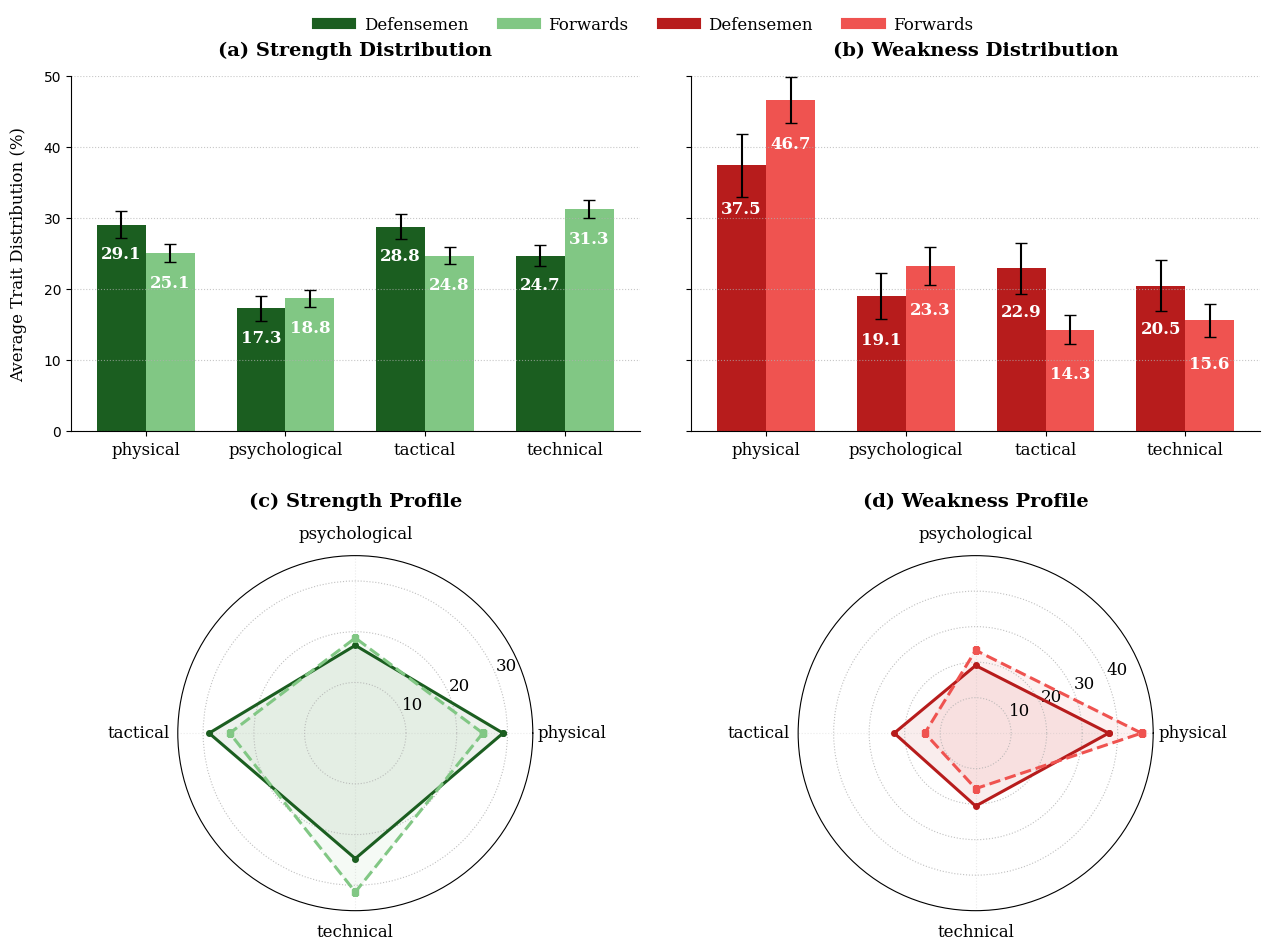

In [20]:
fig = plt.figure(figsize=(13, 10))

# Top row: bar charts
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2, sharey=ax1)

# Bottom row: radar charts
ax3 = fig.add_subplot(2, 2, 3, polar=True)
ax4 = fig.add_subplot(2, 2, 4, polar=True)

plot_positions = ["D", "F"]
labels = {"D": "Defenseman", "F": "Forward"}
x = np.arange(len(trait_order))
bar_width = 0.35

common_ymax = 50
common_yticks = np.arange(0, 55, 10)
# =====================
# (a) Strength bar
# =====================
colors_strength = {"D": "#1B5E20", "F": "#81C784"}

for i, pos in enumerate(plot_positions):
    dat = summary_strength[summary_strength["position"] == pos].sort_values("trait")
    offset = (i - 0.5) * bar_width

    bars = ax1.bar(
        x + offset,
        dat["mean_pct"].to_numpy(),
        yerr=dat["ci95_pct"].to_numpy(),
        width=bar_width,
        capsize=4,
        label=labels[pos],
        color=colors_strength[pos]
    )
    for bar in bars:
      height = bar.get_height()
      ax1.text(
          bar.get_x() + bar.get_width() / 2,
          height - 3,
          f"{height:.1f}",
          ha="center",
          va="top",
          fontsize=12,
          color="white",
          fontfamily="serif",
          fontweight="bold"
      )

ax1.set_xticks(x)
ax1.set_xticklabels(trait_order, fontsize=12, fontfamily="serif")
ax1.set_ylabel("Average Trait Distribution (%)", fontfamily="serif", fontsize=12, labelpad=12)
ax1.set_ylim(0, common_ymax)
ax1.set_yticks(common_yticks)
ax1.set_title("(a) Strength Distribution", fontfamily="serif", fontsize=14, fontweight="bold", pad=15)
ax1.grid(axis="y", linestyle=":", alpha=0.7)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =====================
# (b) Weakness bar
# =====================
colors_weakness = {"D": "#B71C1C", "F": "#EF5350"}

for i, pos in enumerate(plot_positions):
    dat = summary_weakness[summary_weakness["position"] == pos].sort_values("trait")
    offset = (i - 0.5) * bar_width

    bars = ax2.bar(
        x + offset,
        dat["mean_pct"].to_numpy(),
        yerr=dat["ci95_pct"].to_numpy(),
        width=bar_width,
        capsize=4,
        label=labels[pos],
        color=colors_weakness[pos]
    )

    for bar in bars:
      height = bar.get_height()
      ax2.text(
          bar.get_x() + bar.get_width() / 2,
          height - 5,
          f"{height:.1f}",
          ha="center",
          va="top",
          fontsize=12,
          color="white",
          fontfamily="serif",
          fontweight="bold"
      )

ax2.set_xticks(x)
ax2.set_xticklabels(trait_order, fontsize=12, fontfamily="serif")
ax2.set_ylim(0, common_ymax)
ax2.set_yticks(common_yticks)
ax2.tick_params(axis="y", labelleft=False)
ax2.set_title("(b) Weakness Distribution", fontfamily="serif", fontsize=14, fontweight="bold", pad=15)
ax2.grid(axis="y", linestyle=":", alpha=0.7)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# =====================
# Common radar setup
# =====================
positions = ["D", "F"]
angles = np.linspace(0, 2 * np.pi, len(trait_order), endpoint=False).tolist()
angles += angles[:1]

# =====================
# (c) Strength radar
# =====================
pos_style_strength = {
    "D": {"color": "#1B5E20", "ls": "-", "marker": "o", "name": "Defenseman"},
    "F": {"color": "#81C784", "ls": "--", "marker": "s", "name": "Forward"}
}

for pos in positions:
    dat_pos = (
        summary_strength[summary_strength["position"] == pos]
        .set_index("trait")
        .reindex(trait_order)
    )

    values = dat_pos["mean_pct"].to_list()
    values += values[:1]

    ax3.plot(
        angles, values,
        color=pos_style_strength[pos]["color"],
        linestyle=pos_style_strength[pos]["ls"],
        marker=pos_style_strength[pos]["marker"],
        markersize=4,
        linewidth=2.2
    )
    ax3.fill(angles, values, color=pos_style_strength[pos]["color"], alpha=0.08)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(trait_order, fontsize=12, fontfamily="serif")
ax3.tick_params(axis="x", pad=18)

for label in ax3.get_xticklabels():
    if label.get_text().lower() in ["psychological", "technical"]:
        x0, y0 = label.get_position()
        label.set_position((x0, y0 + 0.1))

ax3.set_ylim(0, 35)
ax3.set_yticks([10, 20, 30])
ax3.set_yticklabels(["10", "20", "30"], fontsize=12, fontfamily="serif")
ax3.yaxis.grid(True, linestyle=":", alpha=0.8)
ax3.xaxis.grid(True, linestyle=":", alpha=0.25)
ax3.set_title("(c) Strength Profile", fontfamily="serif", fontsize=14, fontweight="bold", pad=35)

# =====================
# (d) Weakness radar
# =====================
pos_style_weakness = {
    "D": {"color": "#B71C1C", "ls": "-", "marker": "o", "name": "Defenseman"},
    "F": {"color": "#EF5350", "ls": "--", "marker": "s", "name": "Forward"}
}

for pos in positions:
    dat_pos = (
        summary_weakness[summary_weakness["position"] == pos]
        .set_index("trait")
        .reindex(trait_order)
    )

    values = dat_pos["mean_pct"].to_list()
    values += values[:1]

    ax4.plot(
        angles, values,
        color=pos_style_weakness[pos]["color"],
        linestyle=pos_style_weakness[pos]["ls"],
        marker=pos_style_weakness[pos]["marker"],
        markersize=4,
        linewidth=2.2
    )
    ax4.fill(angles, values, color=pos_style_weakness[pos]["color"], alpha=0.08)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(trait_order, fontsize=12, fontfamily="serif")
ax4.tick_params(axis="x", pad=18)

for label in ax4.get_xticklabels():
    if label.get_text().lower() in ["psychological", "technical"]:
        x0, y0 = label.get_position()
        label.set_position((x0, y0 + 0.1))

ax4.set_ylim(0, 50)
ax4.set_yticks([10, 20, 30, 40])
ax4.set_yticklabels(["10", "20", "30", "40"], fontsize=12, fontfamily="serif")
ax4.yaxis.grid(True, linestyle=":", alpha=0.8)
ax4.xaxis.grid(True, linestyle=":", alpha=0.25)
ax4.set_title("(d) Weakness Profile", fontfamily="serif", fontsize=14, fontweight="bold", pad=35)

# =====================
# Shared legends
# =====================
bar_handles = [
    Line2D([0], [0], color="#1B5E20", lw=8, label="Defensemen"),
    Line2D([0], [0], color="#81C784", lw=8, label="Forwards"),
    Line2D([0], [0], color="#B71C1C", lw=8, label="Defensemen"),
    Line2D([0], [0], color="#EF5350", lw=8, label="Forwards")
]

fig.legend(
    handles=bar_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=4,
    frameon=False,
    prop={"family": "serif", "size": 12}
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.subplots_adjust(hspace=0.35)
plt.show()

### Pair Permutation Tests

In [15]:
np.random.seed(42)

def paired_permutation_test(a, b, n_perm=5000):
    diffs = a - b
    observed = diffs.mean()
    count = 0

    for _ in range(n_perm):
        flip = np.random.rand(len(a)) < 0.5
        perm_a = np.where(flip, b, a)
        perm_b = np.where(flip, a, b)
        perm_diff = (perm_a - perm_b).mean()

        if abs(perm_diff) >= abs(observed):
            count += 1

    p_value = count / n_perm
    return p_value, observed

def permutation_table_for_position(df, position, pairs, n_perm=5000):
    df_pos = df[df["position"] == position]

    df_wide = df_pos.pivot_table(
        index="player_name",
        columns="trait",
        values="prop"
    )

    rows = []

    for t1, t2 in pairs:
        a = df_wide[t1].values
        b = df_wide[t2].values

        mask = ~np.isnan(a) & ~np.isnan(b)
        a, b = a[mask], b[mask]

        p, obs = paired_permutation_test(a, b, n_perm=n_perm)

        rows.append({
            "position": position,
            "pair": f"{t1} vs {t2}",
            "n_players": len(a),
            "mean_diff": obs,
            "p_value": p
        })

    return pd.DataFrame(rows)

In [16]:
pairs = [
    ("physical", "tactical"),
    ("physical", "technical"),
    ("physical", "psychological"),
    ("tactical", "technical"),
    ("tactical", "psychological"),
    ("technical", "psychological"),
]

table_D_strength = permutation_table_for_position(counts_full_strength, "D", pairs)
table_F_strength = permutation_table_for_position(counts_full_strength, "F", pairs)
table_D_weakness = permutation_table_for_position(counts_full_weakness, "D", pairs)
table_F_weakness = permutation_table_for_position(counts_full_weakness, "F", pairs)

print(pd.concat([table_D_strength, table_F_strength]))
print(pd.concat([table_D_weakness, table_F_weakness]))

  position                        pair  n_players  mean_diff  p_value
0        D        physical vs tactical        218   0.003036   0.8518
1        D       physical vs technical        218   0.043980   0.0026
2        D   physical vs psychological        218   0.118207   0.0000
3        D       tactical vs technical        218   0.040944   0.0036
4        D   tactical vs psychological        218   0.115171   0.0000
5        D  technical vs psychological        218   0.074227   0.0000
0        F        physical vs tactical        413   0.003866   0.7070
1        F       physical vs technical        413  -0.061753   0.0000
2        F   physical vs psychological        413   0.063757   0.0000
3        F       tactical vs technical        413  -0.065619   0.0000
4        F   tactical vs psychological        413   0.059891   0.0000
5        F  technical vs psychological        413   0.125510   0.0000
  position                        pair  n_players  mean_diff  p_value
0        D        ph

## 2. Frequent Phrases in Trait Descriptions

### Figure 3: Phraseclouds for Strength Traits

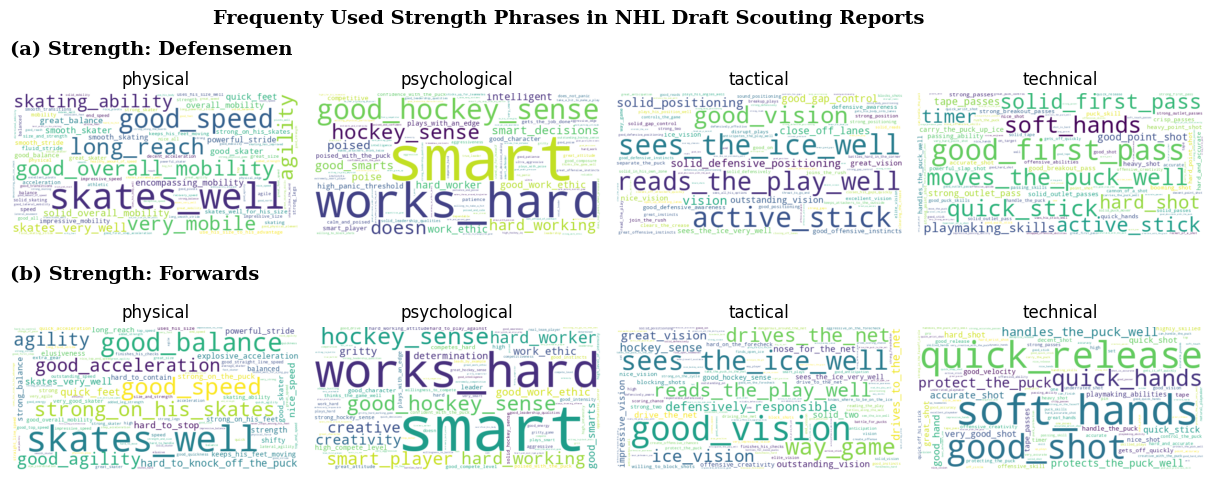

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

position_labels = {
    "D": "(a) Strength: Defensemen",
    "F": "(b) Strength: Forwards"
}

positions = ["D", "F"]

for row, pos in enumerate(positions):

    for col, trait in enumerate(trait_order):

        ax = axes[row, col]

        subset = df_strength[
            (df_strength["position"] == pos) &
            (df_strength["trait"] == trait)
        ]

        phrases = subset["phrase"].tolist()

        if len(phrases) == 0:
            ax.axis("off")
            ax.set_title(trait, fontsize=12)
            continue

        text = " ".join(p.replace(" ", "_") for p in phrases)

        wc = WordCloud(
            width=600,
            height=300,
            background_color="white",
            collocations=False
        ).generate(text)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")

        ax.set_title(trait, fontsize=12)

    # row labels
    fig.text(
        0.07,
        0.9 if pos == "D" else 0.45,
        position_labels[pos],
        fontsize=14,
        fontweight="bold",
        fontfamily="serif",
        va="center"
    )

# overall title
fig.suptitle(
    "Frequenty Used Strength Phrases in NHL Draft Scouting Reports",
    fontsize=14,
    fontweight="bold",
    fontfamily="serif"
)

plt.tight_layout(rect=[0.06, 0, 1, 0.94])
fig.subplots_adjust(hspace=0.35)
plt.show()

### Figure 3: Phraseclouds for Weakness Traits

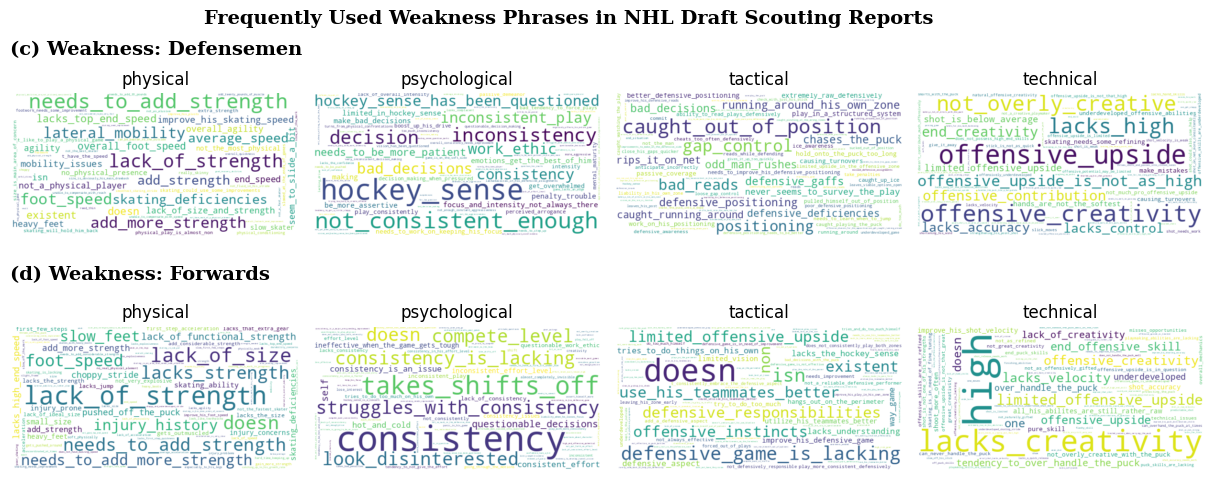

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

position_labels = {
    "D": "(c) Weakness: Defensemen",
    "F": "(d) Weakness: Forwards"
}

positions = ["D", "F"]

for row, pos in enumerate(positions):

    for col, trait in enumerate(trait_order):

        ax = axes[row, col]

        subset = df_weakness[
            (df_weakness["position"] == pos) &
            (df_weakness["trait"] == trait)
        ]

        phrases = subset["phrase"].tolist()

        if len(phrases) == 0:
            ax.axis("off")
            ax.set_title(trait, fontsize=12)
            continue

        text = " ".join(p.replace(" ", "_") for p in phrases)

        wc = WordCloud(
            width=600,
            height=300,
            background_color="white",
            collocations=False
        ).generate(text)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")

        ax.set_title(trait, fontsize=12)

    # row labels
    fig.text(
        0.07,
        0.9 if pos == "D" else 0.45,
        position_labels[pos],
        fontsize=14,
        fontweight="bold",
        fontfamily="serif",
        va="center"
    )

# overall title
fig.suptitle(
    "Frequently Used Weakness Phrases in NHL Draft Scouting Reports",
    fontsize=14,
    fontweight="bold",
    fontfamily="serif"
)

plt.tight_layout(rect=[0.06, 0, 1, 0.94])
fig.subplots_adjust(hspace=0.35)
plt.show()

## 3. Temporal Trends in Trait Distributions

### Data Wrangling for Stacked Area Chart

In [30]:
counts_strength_year_total = (
    df_strength
    .groupby(["draft_year", "position", "trait"])
    .size()
    .reset_index(name="n_trait")
)

totals_strength_year_total = counts_strength_year_total.groupby(
    ["draft_year", "position"]
)["n_trait"].transform("sum")

counts_strength_year_total["prop_year"] = (
    counts_strength_year_total["n_trait"] / totals_strength_year_total
)

counts_strength_year_total["pct_year"] = 100 * counts_strength_year_total["prop_year"]

In [31]:
counts_weakness_year_total = (
    df_weakness
    .groupby(["draft_year", "position", "trait"])
    .size()
    .reset_index(name="n_trait")
)

totals_weakness_year_total = counts_weakness_year_total.groupby(
    ["draft_year", "position"]
)["n_trait"].transform("sum")

counts_weakness_year_total["prop_year"] = (
    counts_weakness_year_total["n_trait"] / totals_weakness_year_total
)

counts_weakness_year_total["pct_year"] = 100 * counts_weakness_year_total["prop_year"]

### Data Wrangling for Radar Chart

In [41]:
counts_year_strength = (
    df_strength
      .groupby(["draft_year", "position", "player_name", "trait"])
      .size()
      .reset_index(name="n")
)

# within-player proportions (per year, per position)
totals_year_strength = counts_year_strength.groupby(
    ["draft_year", "position", "player_name"]
)["n"].transform("sum")

counts_year_strength["prop"] = np.where(totals_year_strength > 0,
                                        counts_year_strength["n"] / totals_year_strength,
                                        0)

# summaries by (draft_year, position, trait)
summary_year_strength = (
    counts_year_strength
      .groupby(["draft_year", "position", "trait"], as_index=False)
      .agg(
          mean_prop=("prop", "mean"),
          sd_prop=("prop", "std"),
          n_players=("player_name", "nunique")
      )
)

# standard error + 95% CI
summary_year_strength["sem"] = summary_year_strength["sd_prop"] / np.sqrt(summary_year_strength["n_players"])
summary_year_strength["ci95"] = 1.96 * summary_year_strength["sem"]

# convert to percentages for plotting
summary_year_strength["mean_pct"] = 100 * summary_year_strength["mean_prop"]
summary_year_strength["ci95_pct"] = 100 * summary_year_strength["ci95"]

# ensure trait ordering is consistent with earlier bar plot
summary_year_strength["trait"] = pd.Categorical(
    summary_year_strength["trait"],
    categories=trait_order,   # ["physical", "psychological", "tactical", "technical"]
    ordered=True
)
summary_year_strength = summary_year_strength.sort_values(["position", "trait", "draft_year"])

In [42]:
# per-player counts by draft year
counts_year_weakness = (
    df_weakness
      .groupby(["draft_year", "position", "player_name", "trait"])
      .size()
      .reset_index(name="n")
)

# within-player proportions (per year, per position)
totals_year_weakness = counts_year_weakness.groupby(
    ["draft_year", "position", "player_name"]
)["n"].transform("sum")

counts_year_weakness["prop"] = np.where(totals_year_weakness > 0,
                                        counts_year_weakness["n"] / totals_year_weakness,
                                        0)

# summaries by (draft_year, position, trait)
summary_year_weakness = (
    counts_year_weakness
      .groupby(["draft_year", "position", "trait"], as_index=False)
      .agg(
          mean_prop=("prop", "mean"),
          sd_prop=("prop", "std"),
          n_players=("player_name", "nunique")
      )
)

# convert to percentages for plotting
summary_year_weakness["mean_pct"] = 100 * summary_year_weakness["mean_prop"]

# ensure trait ordering is consistent with earlier bar plot
summary_year_weakness["trait"] = pd.Categorical(
    summary_year_weakness["trait"],
    categories=trait_order,   # ["physical", "psychological", "tactical", "technical"]
    ordered=True
)
summary_year_weakness = summary_year_weakness.sort_values(["position", "trait", "draft_year"])

In [43]:
summary_year_strength["trait"] = pd.Categorical(
    summary_year_strength["trait"],
    categories=trait_order,
    ordered=True
)

summary_year_weakness["trait"] = pd.Categorical(
    summary_year_weakness["trait"],
    categories=trait_order,
    ordered=True
)

### Figure 4: Stacked Area Chart

In [33]:
trait_colors_strength = {
    "physical": "#1B5E20",
    "psychological": "#43A047",
    "tactical": "#81C784",
    "technical": "#C8E6C9"
}

trait_colors_weakness = {
    "physical": "#B71C1C",
    "psychological": "#D32F2F",
    "tactical": "#EF5350",
    "technical": "#FFCDD2"
}

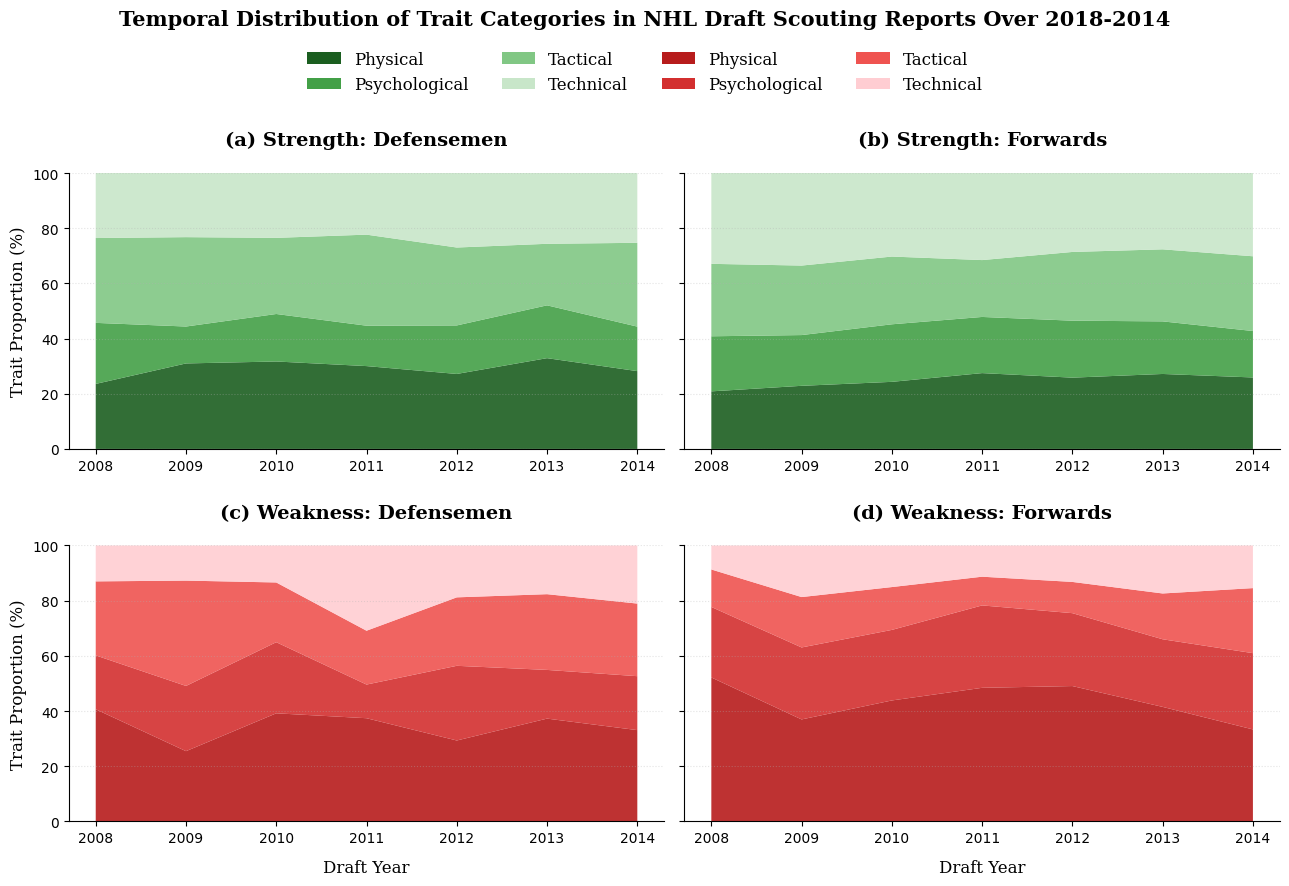

In [39]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 9),
    sharey="col"   # share y-axis within each column
)

ax1, ax2, ax3, ax4 = axes.flatten()

subplot_labels = {
    "D_strength": "(a) Strength: Defensemen",
    "F_strength": "(b) Strength: Forwards",
    "D_weakness": "(c) Weakness: Defensemen",
    "F_weakness": "(d) Weakness: Forwards"
}

# ======================
# Strength plots
# ======================

for ax, pos in zip([ax1, ax2], ["D", "F"]):

    df_pos = counts_strength_year_total[
        counts_strength_year_total["position"] == pos
    ].copy()

    wide_pos = (
        df_pos.pivot(index="draft_year", columns="trait", values="pct_year")
        .reindex(columns=trait_order)
        .sort_index()
        .fillna(0)
    )

    x = wide_pos.index.to_numpy()
    y = [wide_pos[trait].to_numpy() for trait in trait_order]
    colors = [trait_colors_strength[trait] for trait in trait_order]

    ax.stackplot(x, y, labels=trait_order, colors=colors, alpha=0.9)

    ax.set_title(
        subplot_labels[f"{pos}_strength"],
        fontfamily="serif",
        fontsize=14,
        fontweight="bold",
        pad=20
    )

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    if ax in [ax1, ax3]:
      ax.set_ylabel("Trait Proportion (%)", fontfamily="serif", size=12)

    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ======================
# Weakness plots
# ======================

for ax, pos in zip([ax3, ax4], ["D", "F"]):

    df_pos = counts_weakness_year_total[
        counts_weakness_year_total["position"] == pos
    ].copy()

    wide_pos = (
        df_pos.pivot(index="draft_year", columns="trait", values="pct_year")
        .reindex(columns=trait_order)
        .sort_index()
        .fillna(0)
    )

    x = wide_pos.index.to_numpy()
    y = [wide_pos[trait].to_numpy() for trait in trait_order]
    colors = [trait_colors_weakness[trait] for trait in trait_order]

    ax.stackplot(x, y, labels=trait_order, colors=colors, alpha=0.9)

    ax.set_title(
        subplot_labels[f"{pos}_weakness"],
        fontfamily="serif",
        fontsize=14,
        fontweight="bold",
        pad=20
    )

    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    if ax in [ax1, ax3]:
      ax.set_ylabel("Trait Proportion (%)", fontfamily="serif", size=12)

    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


ax2.tick_params(axis="y", labelleft=False)
ax4.tick_params(axis="y", labelleft=False)

# X-axis label for bottom row
ax3.set_xlabel("Draft Year", fontfamily="serif", labelpad=10, size=12)
ax4.set_xlabel("Draft Year", fontfamily="serif", labelpad=10, size=12)

# ======================
# Shared legend
# ======================

# Strength legend items
strength_handles = [
    Patch(facecolor=trait_colors_strength[t], label=f"{t.capitalize()}")
    for t in trait_order
]

# Weakness legend items
weakness_handles = [
    Patch(facecolor=trait_colors_weakness[t], label=f"{t.capitalize()}")
    for t in trait_order
]

handles = strength_handles + weakness_handles

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    prop={"family": "serif", "size": 12}
)
# ======================
# Overall title
# ======================

fig.suptitle(
    "Temporal Distribution of Trait Categories in NHL Draft Scouting Reports Over 2018-2014",
    fontfamily="serif",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.subplots_adjust(hspace=0.35)
plt.show()

### Figure 5: Radar Chart

In [44]:
strength_style = {
    "D": {"color": "#1B5E20", "ls": "-",  "marker": "o", "name": "Defenseman"},
    "F": {"color": "#81C784", "ls": "--", "marker": "s", "name": "Forward"}
}

weakness_style = {
    "D": {"color": "#B71C1C", "ls": "-",  "marker": "o", "name": "Defenseman"},
    "F": {"color": "#EF5350", "ls": "--", "marker": "s", "name": "Forward"}
}

years_to_plot = [2008, 2009, 2013, 2014]
angles = np.linspace(0, 2 * np.pi, len(trait_order), endpoint=False).tolist()
angles += angles[:1]

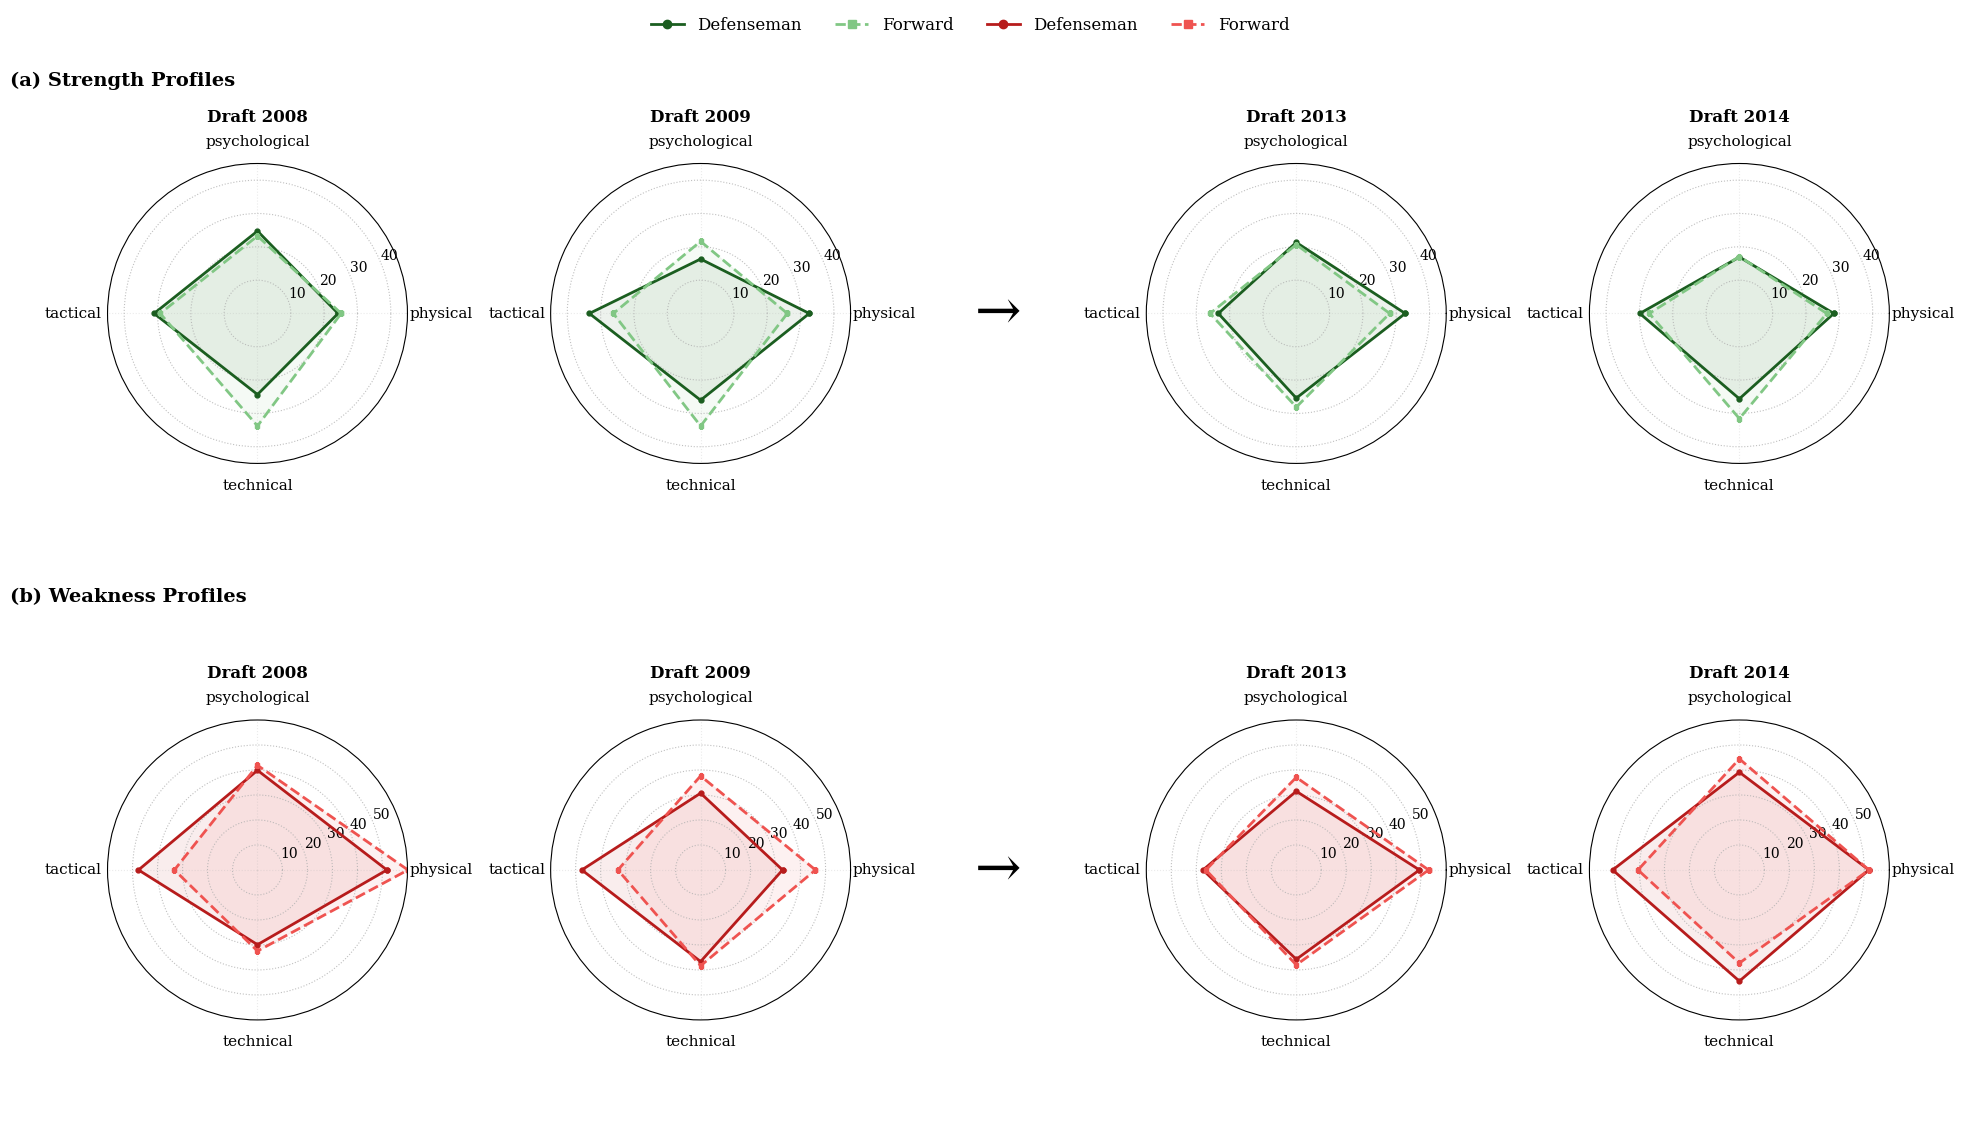

In [46]:
fig = plt.figure(figsize=(20, 12))

# 2 rows x 5 cols
gs = gridspec.GridSpec(
    2, 5,
    width_ratios=[1.6, 1.6, 0.05, 1.6, 1.6],
    height_ratios=[1, 1]
)

fig.subplots_adjust(wspace=0.05, hspace=0.35)

# ---------- helper function ----------
def plot_radar_row(row_idx, summary_data, style_dict, r_max, yticks, row_label):
    axes = [
        fig.add_subplot(gs[row_idx, 0], polar=True),
        fig.add_subplot(gs[row_idx, 1], polar=True),
        fig.add_subplot(gs[row_idx, 3], polar=True),
        fig.add_subplot(gs[row_idx, 4], polar=True)
    ]
    ax_arrow = fig.add_subplot(gs[row_idx, 2])
    ax_arrow.axis("off")
    ax_arrow.text(
        0.5, 0.5, "→",
        ha="center", va="center",
        fontsize=40,
        fontfamily="serif"
    )

    for ax, year in zip(axes, years_to_plot):
        dat_year = summary_data[summary_data["draft_year"] == year]

        for pos in positions:
            dat_pos = (
                dat_year[dat_year["position"] == pos]
                .set_index("trait")
                .reindex(trait_order)
                .fillna({"mean_pct": 0})
            )

            values = dat_pos["mean_pct"].to_list()
            values += values[:1]

            ax.plot(
                angles, values,
                color=style_dict[pos]["color"],
                linestyle=style_dict[pos]["ls"],
                marker=style_dict[pos]["marker"],
                markersize=3.5,
                linewidth=2.0,
                label=style_dict[pos]["name"]
            )
            ax.fill(
                angles, values,
                color=style_dict[pos]["color"],
                alpha=0.08
            )

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(trait_order, fontsize=11, fontfamily="serif")
        ax.tick_params(axis="x", pad=14)

        for label in ax.get_xticklabels():
            if label.get_text().lower() in ["psychological", "technical"]:
                x, y = label.get_position()
                label.set_position((x, y + 0.08))

        ax.set_ylim(0, r_max)
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(y) for y in yticks], fontsize=10, fontfamily="serif")
        ax.yaxis.grid(True, linestyle=":", alpha=0.8)
        ax.xaxis.grid(True, linestyle=":", alpha=0.25)

        ax.set_title(
            f"Draft {year}",
            fontsize=12,
            fontfamily="serif",
            fontweight="bold",
            pad=30
        )

    # add row label like (a) and (b)
    fig.text(
        0.02, 0.88 if row_idx == 0 else 0.45,
        row_label,
        fontsize=14,
        fontfamily="serif",
        fontweight="bold",
    )

    return axes

# ---------- plot top row: Strength ----------
axes_strength = plot_radar_row(
    row_idx=0,
    summary_data=summary_year_strength,
    style_dict=strength_style,
    r_max=45,
    yticks=[10, 20, 30, 40],
    row_label="(a) Strength Profiles"
)

# ---------- plot bottom row: Weakness ----------
axes_weakness = plot_radar_row(
    row_idx=1,
    summary_data=summary_year_weakness,
    style_dict=weakness_style,
    r_max=60,
    yticks=[10, 20, 30, 40, 50],
    row_label="(b) Weakness Profiles"
)

# ---------- shared legend ----------
legend_handles = [
    # Strength
    Line2D([0], [0],
           color="#1B5E20", linestyle="-", marker="o", lw=2,
           label="Defenseman"),
    Line2D([0], [0],
           color="#81C784", linestyle="--", marker="s", lw=2,
           label="Forward"),

    # Weakness
    Line2D([0], [0],
           color="#B71C1C", linestyle="-", marker="o", lw=2,
           label="Defenseman"),
    Line2D([0], [0],
           color="#EF5350", linestyle="--", marker="s", lw=2,
           label="Forward"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.95),
    frameon=False,
    prop={"family": "serif", "size": 12}
)

plt.tight_layout(rect=[0.03, 0, 1, 0.94])
plt.show()